In [1]:
# YWWA (Yang wajib-wajib aja)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Sklearn
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder,StandardScaler

# Load Model
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Teknik Upsampling dan Under Sampling karena disini dataset nya imbalance parah!
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
data = pd.read_csv("D:\Codink\Project\Machine Learning - Learn\stroke\healthcare-dataset-stroke-data.csv")
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
## Hapus duplikat duls
data.drop_duplicates(inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
bmi_null = data[data['bmi'].isna()]
print(bmi_null['stroke'].value_counts())

# Sepertinya karena ada beberapa data dari label 0 yang ada di sini, kita ga usah drop
# Kita imputate saja!

stroke
0    161
1     40
Name: count, dtype: int64


In [5]:
data.isna().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
# Imputasi Data Null dengan KNN Imputer
from sklearn.impute import KNNImputer

cols = ['age', 'avg_glucose_level', 'bmi']

imputer = KNNImputer(n_neighbors=5)
data[cols] = imputer.fit_transform(data[cols])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [7]:
# checking unbalance target distribution 
data['stroke'].value_counts().reset_index()

,stroke,count
0,0,4861
1,1,249


In [8]:
# Kita drop kolom ID karena tidak berguna
df = data.drop('id', axis=1)
df = pd.DataFrame(df)
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.38,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,26.82,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.00,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.60,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.60,formerly smoked,0


In [9]:
# Split into categorical and numerical
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
# identifikasi Numerical Features
    

C:\Users\user\AppData\Local\Temp\ipykernel_16332\2932788653.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [10]:
## Bisa dipisah Untuk Encoding nanti
num_cont = ['age', 'avg_glucose_level', 'bmi']
num_bin = ['hypertension', 'heart_disease', 'stroke']

In [11]:
# Check Unique data
for i in categorical_features:
    print(f"========{i}==========")
    print(df[i].value_counts().reset_index)
    
categorical_features


========gender==========
<bound method Series.reset_index of gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64>
========ever_married==========
<bound method Series.reset_index of ever_married
Yes    3353
No     1757
Name: count, dtype: int64>
========work_type==========
<bound method Series.reset_index of work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64>
========Residence_type==========
<bound method Series.reset_index of Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64>
========smoking_status==========
<bound method Series.reset_index of smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64>


Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

In [12]:
# Yang other di Gender di ilangin ae
# Karena di di fitur Gender, ada gender "others" yang hanya berisi 1, data kita drop saja
df = df[df["gender"]!= "Other"]
df = df.reset_index(drop=True)

In [13]:
# Category kita bagi lagi, yang binary dan yang OHE
# cat_bin = ['gender', 'ever_married', 'urban_rural']
# cat_multi = ['smoking_status', 'work_type']

In [14]:
## SPLITT DATANYAA YOKKK
X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
## Kita mulai membuatkan Pipeline untuk Preprocessing dan Modelling
# Preprocesseing(encoding) kita pakai column Transformer
# Sebelumnya untuk categori fitur yang binary kita rubah manual terlebih dulu
from sklearn.compose import ColumnTransformer

ss = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary') ## pakai drop if binary biar yang binary jadi 1 kolom saja


preprocessor = ColumnTransformer(transformers=[
    ('num_cont', ss , num_cont),
    ('cat_ohe', ohe, categorical_features),
], remainder='passthrough')
# Rubah Array ke bentuk DataFrame
preprocessor.set_output(transform='pandas')
# X_train['gender'] = X_train['gender'].map({'Female': 0, 'Male':1})

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_cont', ...), ('cat_ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [20]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
pipeline = Pipeline([
    ('preprocess', preprocessor),
    # ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss', # 'logloss' untuk binary classif, 'merror' untuk multiclass, 'rmse' untuk regresi
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [1, 2,3, 5],
    'model__learning_rate': [0.01, 0.05,  0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree' : [0.8, 1.0], 
    'model__scale_pos_weight': [19,22.5, 28] # Sarannya menggunakan 22.5 dari data mayoritas/data minor
    }

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',  # bisa ganti roc_auc kalau imbalance
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 648 candidates, totalling 3240 fits


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:40:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [1, 2, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [17]:
best_model = grid_search.best_estimator_
print(grid_search.best_params_)

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__scale_pos_weight': 19, 'model__subsample': 0.8}


In [18]:
# Coba menggunakan Threshold TUning untuk lebih mengklasifikasi binary
# Di XGBoost, menggunakan probabilitas 0 - 1
y_prob = best_model.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4,]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    print(t, recall_score(y_test, y_pred))

0.2 0.9516129032258065
0.3 0.9516129032258065
0.4 0.9354838709677419


In [19]:
y_pred =  (y_prob > 0.3).astype(int)
print(roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7325772849462365
              precision    recall  f1-score   support

           0       0.99      0.51      0.68       960
           1       0.11      0.95      0.20        62

    accuracy                           0.54      1022
   macro avg       0.55      0.73      0.44      1022
weighted avg       0.94      0.54      0.65      1022



C:\Users\user\AppData\Local\Temp\ipykernel_16332\724221695.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


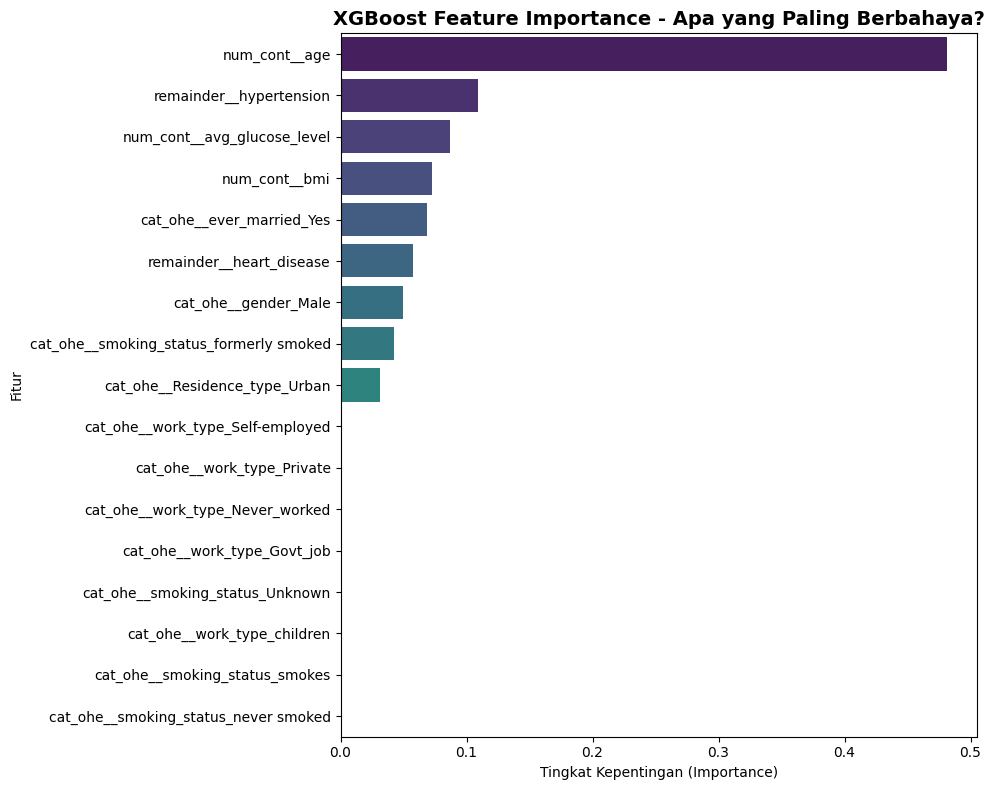

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ekstrak nama fitur yang dihasilkan oleh preprocessor (ColumnTransformer)
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

# 2. Ekstrak nilai feature importance dari model XGBoost
importances = best_model.named_steps['model'].feature_importances_

# 3. Gabungkan menjadi DataFrame agar mudah diurutkan
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Visualisasikan!
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('XGBoost Feature Importance - Apa yang Paling Berbahaya?', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

#### Dari Knowledge tersebut fitur fitur dengan tingkat kepentingan 0 bisa dihapus saja untuk re train modelnya

In [22]:
# 1. Buat salinan X_test agar data asli tidak rusak
analysis_df = X_test.copy()

# 2. Masukkan label asli, probabilitas, dan hasil prediksi (menggunakan threshold 0.3)
analysis_df['Actual_Stroke'] = y_test
analysis_df['Pred_Prob'] = y_prob
analysis_df['Pred_Label'] = (y_prob > 0.3).astype(int)

# 3. Saring pasien yang Aktualnya 0 (Sehat) TAPI diprediksi 1 (Berisiko Stroke)
false_positives = analysis_df[(analysis_df['Actual_Stroke'] == 0) & (analysis_df['Pred_Label'] == 1)]

print(f"Jumlah pasien sehat yang terkena alarm palsu (False Positives): {len(false_positives)} orang\\n")

# 4. Urutkan berdasarkan pasien yang probabilitasnya paling tinggi (paling dicurigai oleh model)
print("Profil 5 Pasien Sehat yang Paling Dicurigai Model Akan Terkena Stroke:")
display(false_positives.sort_values(by='Pred_Prob', ascending=False).head(5))

Jumlah pasien sehat yang terkena alarm palsu (False Positives): 467 orang\n
Profil 5 Pasien Sehat yang Paling Dicurigai Model Akan Terkena Stroke:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,Actual_Stroke,Pred_Prob,Pred_Label
350,Female,79.0,1,1,Yes,Self-employed,Urban,200.28,30.0,formerly smoked,0,0.780892,1
2685,Male,80.0,1,0,Yes,Self-employed,Urban,178.89,27.4,Unknown,0,0.778951,1
3685,Female,80.0,1,0,Yes,Self-employed,Urban,218.00,33.5,Unknown,0,0.778951,1
1971,Female,78.0,1,0,Yes,Self-employed,Rural,201.07,21.8,Unknown,0,0.778951,1
1412,Male,82.0,1,0,Yes,Private,Rural,227.28,33.3,never smoked,0,0.778951,1


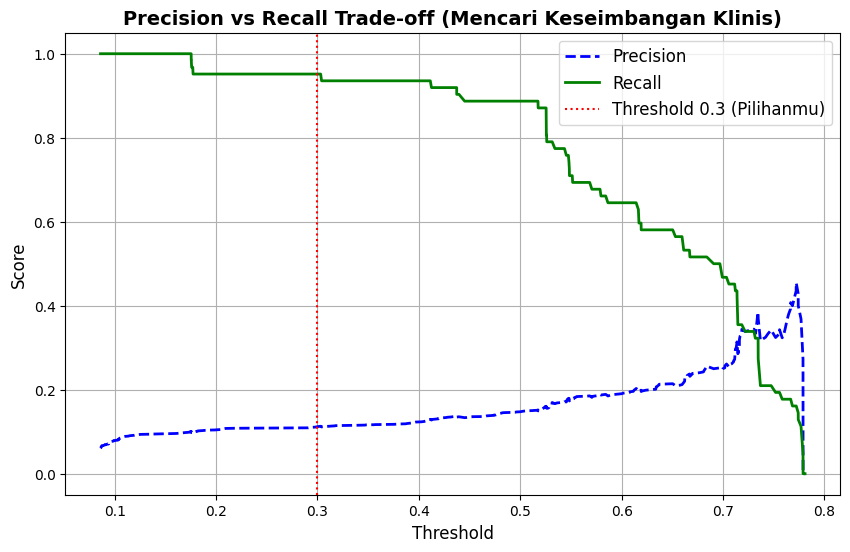

In [23]:
from sklearn.metrics import precision_recall_curve

# 1. Hitung Precision, Recall, dan Threshold secara otomatis
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# 2. Plot grafiknya
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)

# Tambahkan penanda untuk threshold 0.3 milikmu
plt.axvline(x=0.3, color='r', linestyle=':', label='Threshold 0.3 (Pilihanmu)')

plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Precision vs Recall Trade-off (Mencari Keseimbangan Klinis)", fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=12)
plt.grid(True)
plt.show()